# World Cup 2026 Simulation
This will be with 3 models (the highest performing on validation data):
- Logistic Regression (n=10)
- XGBoost (n=10)
- XGBoost (n=20)

## Retrain Top 3 Models

In [28]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss
from sklearn.preprocessing import StandardScaler

MODEL_DATA_DIR = Path('model_data')

N_VALUES = [5, 10, 15, 20]

FEATURES = [
    'elo_diff',
    'form_diff',
    'comp_form_diff'
]

def load_and_engineer(path):
    df = pd.read_csv(path)
    df['elo_diff']       = df['home_elo']       - df['away_elo']
    df['form_diff']      = df['home_form']       - df['away_form']
    df['comp_form_diff'] = df['home_comp_form']  - df['away_comp_form']
    return df


### Train Logistic Regression (n=10)

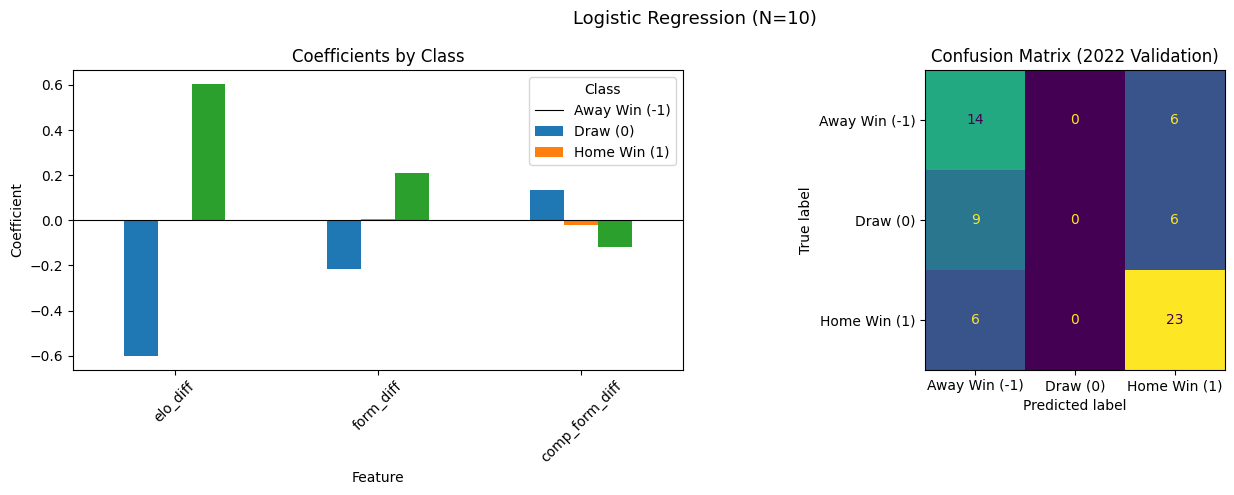

In [29]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

train = load_and_engineer(MODEL_DATA_DIR / 'training_data_10.csv')
val   = load_and_engineer(MODEL_DATA_DIR / 'validation_data_10.csv')

scaler = StandardScaler()
X_train = scaler.fit_transform(train[FEATURES])
X_val   = scaler.transform(val[FEATURES])
y_train, y_val = train['result'], val['result']

lr_best = LogisticRegression(random_state=42, max_iter=1000)
lr_best.fit(X_train, y_train)

LABELS = ['Away Win (-1)', 'Draw (0)', 'Home Win (1)']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Logistic Regression (N=10)', fontsize=13)

# Coefficient bar chart — one set of coefficients per class
coef_df = pd.DataFrame(lr_best.coef_, columns=FEATURES, index=lr_best.classes_)
coef_df.T.plot(kind='bar', ax=axes[0])
axes[0].set_title('Coefficients by Class')
axes[0].set_xlabel('Feature')
axes[0].set_ylabel('Coefficient')
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title='Class', labels=LABELS)

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_val, lr_best.predict(X_val),
    display_labels=LABELS,
    ax=axes[1], colorbar=False
)
axes[1].set_title('Confusion Matrix (2022 Validation)')

plt.tight_layout()
plt.show()

### Train XGBoost (n=10, 20)

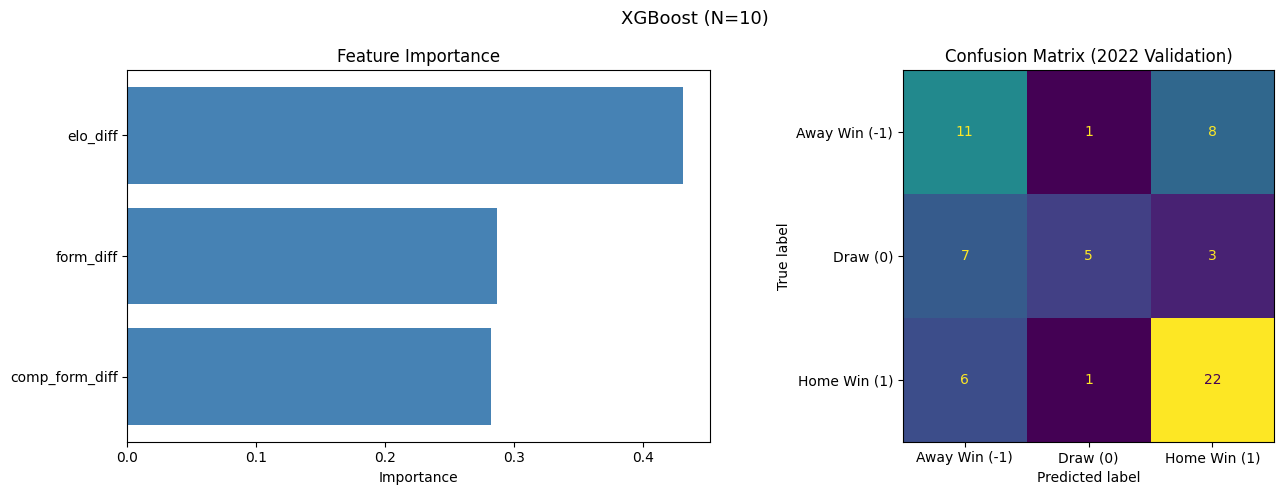

In [30]:
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

xgb_results = []

# Encode labels to 0,1,2 as XGBoost requires non-negative integer classes
le = LabelEncoder()

X_train, y_train = train[FEATURES].values, le.fit_transform(train['result'].values) # type: ignore
X_val,   y_val   = val[FEATURES].values,   le.transform(val['result'].values) # type: ignore

xgb_best_10 = XGBClassifier(
    n_estimators=100, max_depth=3, learning_rate=0.1,
    subsample=0.8, reg_lambda=2.0,
    random_state=42, eval_metric='mlogloss', verbosity=0,
)
xgb_best_10.fit(X_train, y_train)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('XGBoost (N=10)', fontsize=13)

# Feature importance
axes[0].barh(FEATURES, xgb_best_10.feature_importances_, color='steelblue')
axes[0].set_title('Feature Importance')
axes[0].set_xlabel('Importance')
axes[0].invert_yaxis()

# Confusion matrix — decode labels back to -1/0/1 for display
ConfusionMatrixDisplay.from_predictions(
    le.inverse_transform(y_val), le.inverse_transform(xgb_best_10.predict(X_val)),
    display_labels=LABELS,
    ax=axes[1], colorbar=False
)
axes[1].set_title('Confusion Matrix (2022 Validation)')

plt.tight_layout()
plt.show()

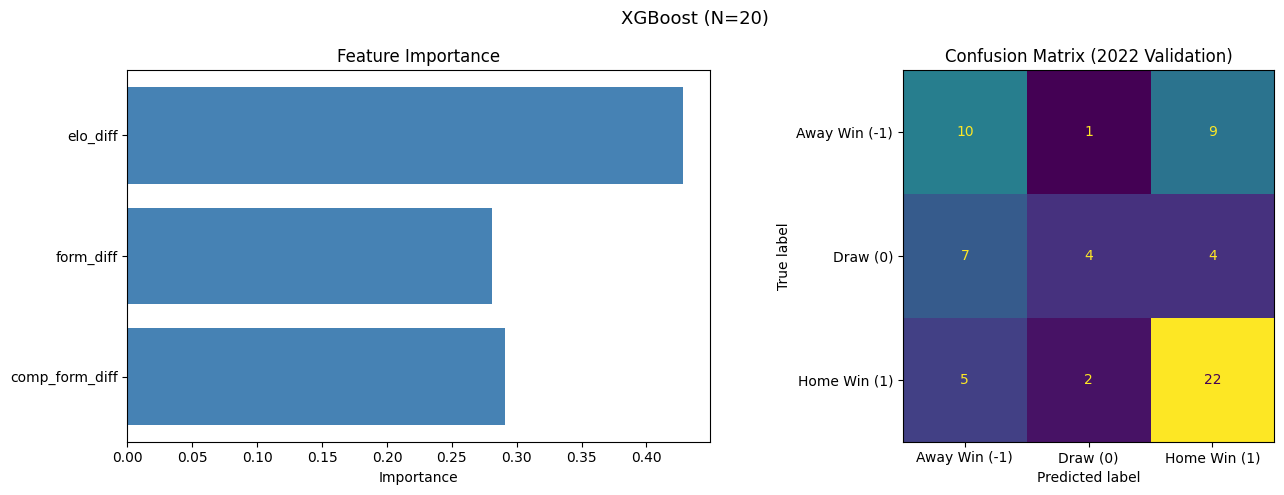

In [31]:
train = load_and_engineer(MODEL_DATA_DIR / 'training_data_20.csv')
val   = load_and_engineer(MODEL_DATA_DIR / 'validation_data_20.csv')

X_train, y_train = train[FEATURES].values, le.fit_transform(train['result'].values)
X_val,   y_val   = val[FEATURES].values,   le.transform(val['result'].values)

xgb_best_20 = XGBClassifier(
    n_estimators=100, max_depth=3, learning_rate=0.1,
    subsample=0.8, reg_lambda=2.0,
    random_state=42, eval_metric='mlogloss', verbosity=0,
)
xgb_best_20.fit(X_train, y_train)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('XGBoost (N=20)', fontsize=13)

# Feature importance
axes[0].barh(FEATURES, xgb_best_20.feature_importances_, color='steelblue')
axes[0].set_title('Feature Importance')
axes[0].set_xlabel('Importance')
axes[0].invert_yaxis()

# Confusion matrix — decode labels back to -1/0/1 for display
ConfusionMatrixDisplay.from_predictions(
    le.inverse_transform(y_val), le.inverse_transform(xgb_best_20.predict(X_val)),
    display_labels=LABELS,
    ax=axes[1], colorbar=False
)
axes[1].set_title('Confusion Matrix (2022 Validation)')

plt.tight_layout()
plt.show()

## Logistic Regression n=10 World Cup Model Predictions

In [ ]:
import random

N_SIMS = 10_000

fixtures_lr = pd.read_csv(MODEL_DATA_DIR / 'fixtures_2026_n10.csv')

# Get model probabilities for each fixture — classes are [-1, 0, 1]
X_fixtures = scaler.transform(fixtures_lr[FEATURES])
probs_lr = lr_best.predict_proba(X_fixtures)  # shape (72, 3), columns = [-1, 0, 1]
classes = list(lr_best.classes_)              # [-1, 0, 1]

# Attach probs to fixtures for easy lookup
fixtures_lr['p_away'] = probs_lr[:, classes.index(-1)]
fixtures_lr['p_draw'] = probs_lr[:, classes.index(0)]
fixtures_lr['p_home'] = probs_lr[:, classes.index(1)]

GROUPS = sorted(fixtures_lr['group'].unique())

# Accumulate points per team per simulation
sim_points = {g: {} for g in GROUPS}
for g in GROUPS:
    teams = pd.unique(fixtures_lr[fixtures_lr['group'] == g][['home_team', 'away_team']].values.ravel())
    sim_points[g] = {t: np.zeros(N_SIMS) for t in teams}

for sim in range(N_SIMS):
    for _, row in fixtures_lr.iterrows():
        outcome = random.choices([-1, 0, 1], weights=[row['p_away'], row['p_draw'], row['p_home']])[0]
        if outcome == 1:    # home win
            sim_points[row['group']][row['home_team']][sim] += 3
        elif outcome == -1: # away win
            sim_points[row['group']][row['away_team']][sim] += 3
        else:               # draw
            sim_points[row['group']][row['home_team']][sim] += 1
            sim_points[row['group']][row['away_team']][sim] += 1

# Average expected points across simulations
print('=== Logistic Regression (N=10) — Expected Group Points ===\n')
group_tables_lr = {}
for g in GROUPS:
    rows = [{'team': t, 'expected_pts': round(float(np.mean(pts)), 2)}
            for t, pts in sim_points[g].items()]
    table = pd.DataFrame(rows).sort_values('expected_pts', ascending=False).reset_index(drop=True)
    table.index += 1
    group_tables_lr[g] = table
    print(f'Group {g}')
    print(table.to_string())
    print()

### Visualize groups and see who moves on to knockouts

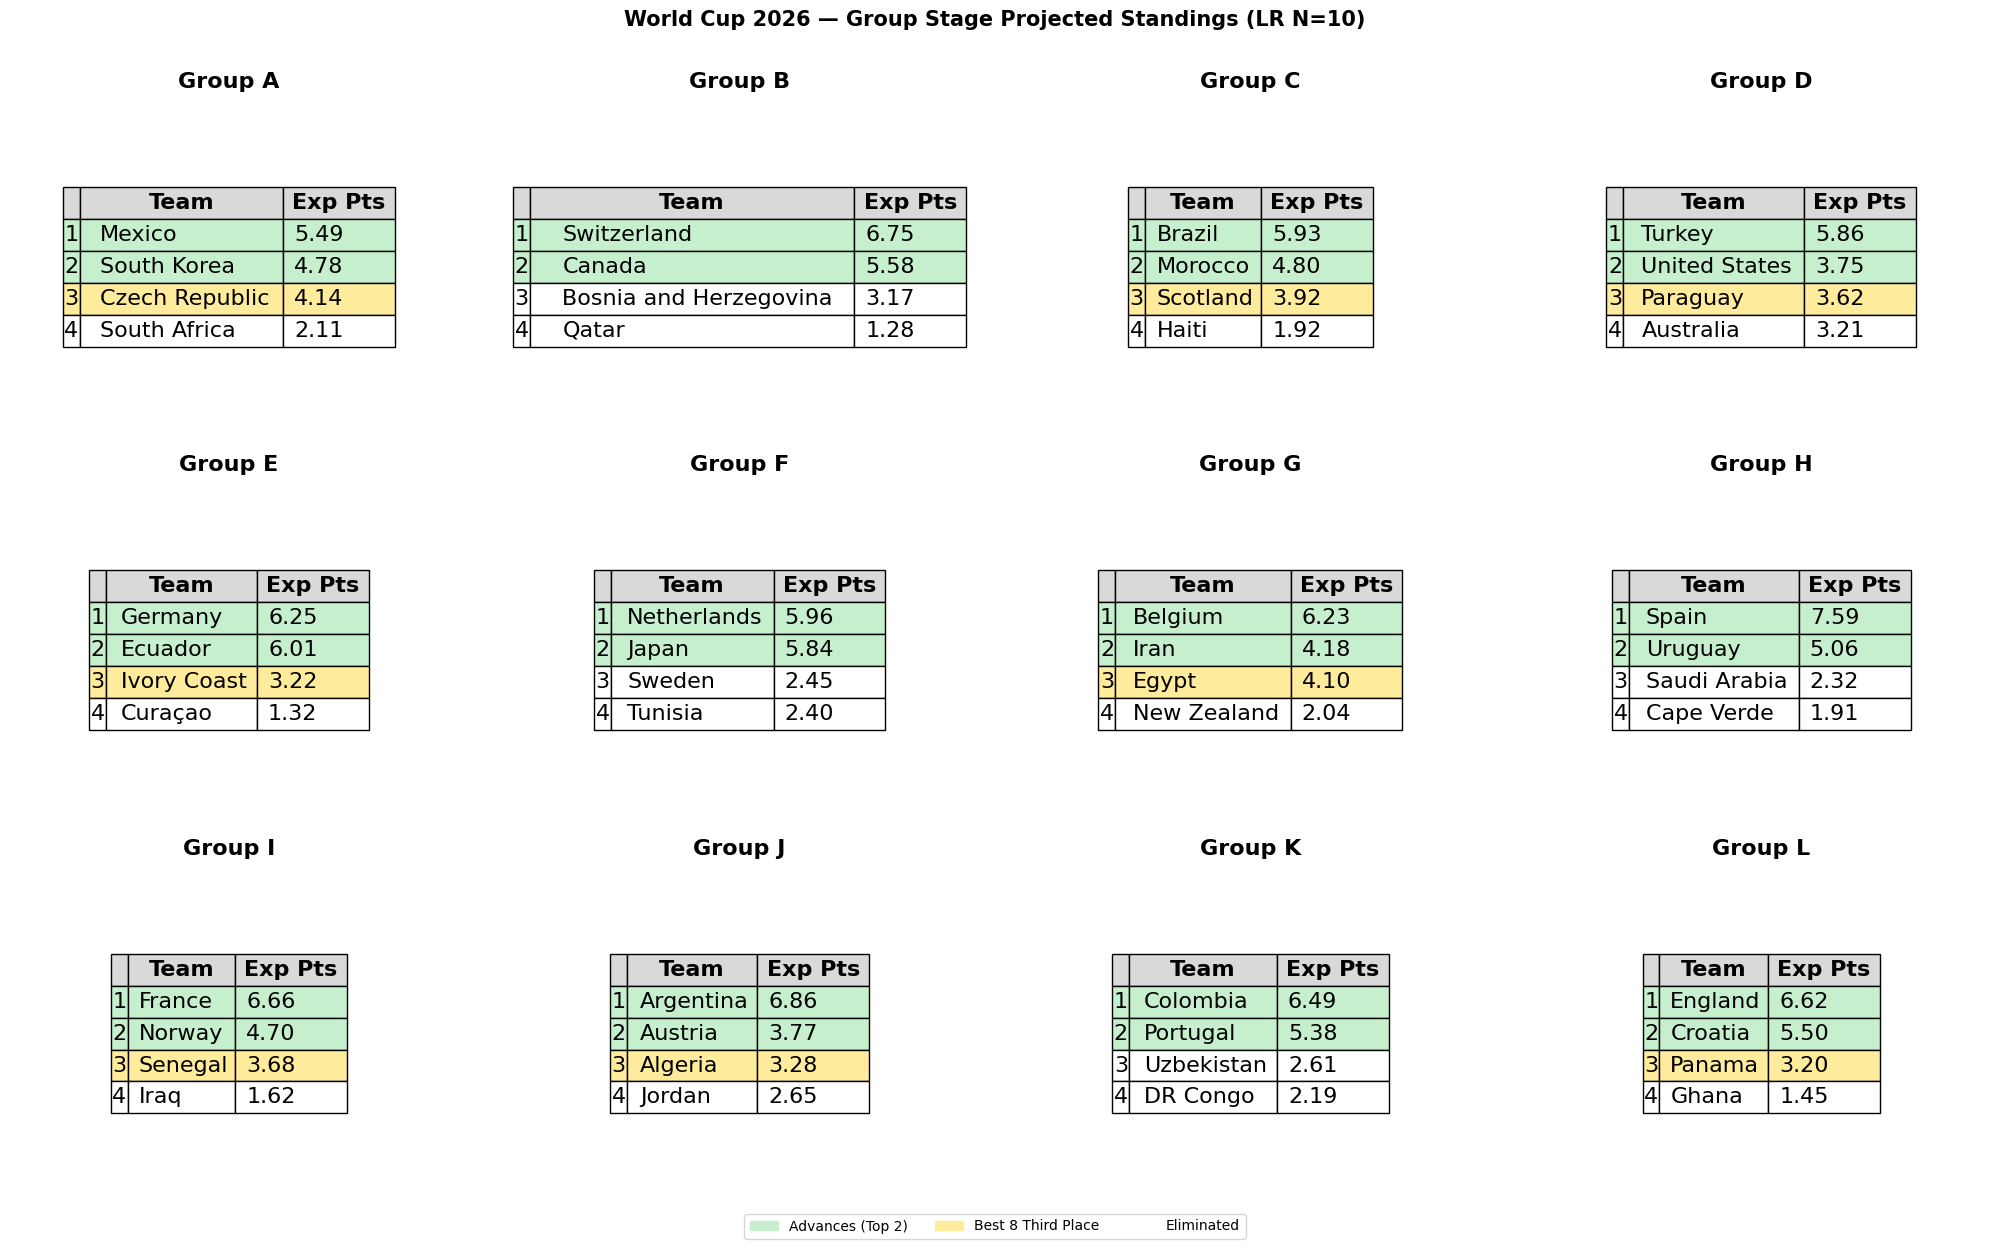

In [33]:
import matplotlib.patches as mpatches

# Find the 3rd place team from each group and rank them
third_place = []
for g, table in group_tables_lr.items():
    row = table.iloc[2]
    third_place.append({'group': g, 'team': row['team'], 'expected_pts': row['expected_pts']})

third_place_df = pd.DataFrame(third_place).sort_values('expected_pts', ascending=False).reset_index(drop=True)
best_8_third = set(third_place_df.head(8)['team'])

COLOR_GREEN  = '#c6efce'
COLOR_YELLOW = '#ffeb9c'
COLOR_WHITE  = '#ffffff'
COLOR_GRAY   = '#d9d9d9'

fig, axes = plt.subplots(3, 4, figsize=(20, 12))
fig.suptitle('World Cup 2026 — Group Stage Projected Standings (LR N=10)', fontsize=15, fontweight='bold', y=1.01)

for idx, g in enumerate(GROUPS):
    ax = axes[idx // 4][idx % 4]
    ax.axis('off')
    ax.set_title(f'Group {g}', fontweight='bold', fontsize=16, pad=4)

    table = group_tables_lr[g]
    cell_text, cell_colors = [], []

    for rank, row in table.iterrows():
        team, pts = row['team'], row['expected_pts']
        if rank <= 2:
            bg = COLOR_GREEN
        elif team in best_8_third:
            bg = COLOR_YELLOW
        else:
            bg = COLOR_WHITE
        cell_text.append([str(rank), team, f'{pts:.2f}'])
        cell_colors.append([bg, bg, bg])

    tbl = ax.table(
        cellText=cell_text,
        colLabels=['', 'Team', 'Exp Pts'],
        cellColours=cell_colors,
        cellLoc='left',
        loc='center',
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(16)
    tbl.scale(1, 1.5)
    for j in range(3):
        tbl[(0, j)].set_text_props(fontweight='bold')
        tbl[(0, j)].set_facecolor(COLOR_GRAY)
    tbl.auto_set_column_width([0, 1, 2])

legend_patches = [
    mpatches.Patch(color=COLOR_GREEN,  label='Advances (Top 2)'),
    mpatches.Patch(color=COLOR_YELLOW, label='Best 8 Third Place'),
    mpatches.Patch(color=COLOR_WHITE,  label='Eliminated'),
]
fig.legend(handles=legend_patches, loc='lower center', ncol=3, fontsize=10, frameon=True, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.show()

---
## XGBoost (n=10)

In [34]:
fixtures_xgb10 = pd.read_csv(MODEL_DATA_DIR / 'fixtures_2026_n10.csv')

X_fixtures_xgb10 = fixtures_xgb10[FEATURES].values
probs_xgb10 = xgb_best_10.predict_proba(X_fixtures_xgb10)  # classes encoded: 0=-1, 1=0, 2=1
xgb_classes = list(le.classes_)  # [-1, 0, 1]

fixtures_xgb10['p_away'] = probs_xgb10[:, xgb_classes.index(-1)]
fixtures_xgb10['p_draw'] = probs_xgb10[:, xgb_classes.index(0)]
fixtures_xgb10['p_home'] = probs_xgb10[:, xgb_classes.index(1)]

sim_points_xgb10 = {g: {} for g in GROUPS}
for g in GROUPS:
    teams = pd.unique(fixtures_xgb10[fixtures_xgb10['group'] == g][['home_team', 'away_team']].values.ravel())
    sim_points_xgb10[g] = {t: np.zeros(N_SIMS) for t in teams}

for sim in range(N_SIMS):
    for _, row in fixtures_xgb10.iterrows():
        outcome = random.choices([-1, 0, 1], weights=[row['p_away'], row['p_draw'], row['p_home']])[0]
        if outcome == 1:
            sim_points_xgb10[row['group']][row['home_team']][sim] += 3
        elif outcome == -1:
            sim_points_xgb10[row['group']][row['away_team']][sim] += 3
        else:
            sim_points_xgb10[row['group']][row['home_team']][sim] += 1
            sim_points_xgb10[row['group']][row['away_team']][sim] += 1

group_tables_xgb10 = {}
for g in GROUPS:
    rows = [{'team': t, 'expected_pts': round(float(np.mean(pts)), 2)}
            for t, pts in sim_points_xgb10[g].items()]
    table = pd.DataFrame(rows).sort_values('expected_pts', ascending=False).reset_index(drop=True)
    table.index += 1
    group_tables_xgb10[g] = table

print('XGBoost N=10 done.')

XGBoost N=10 done.


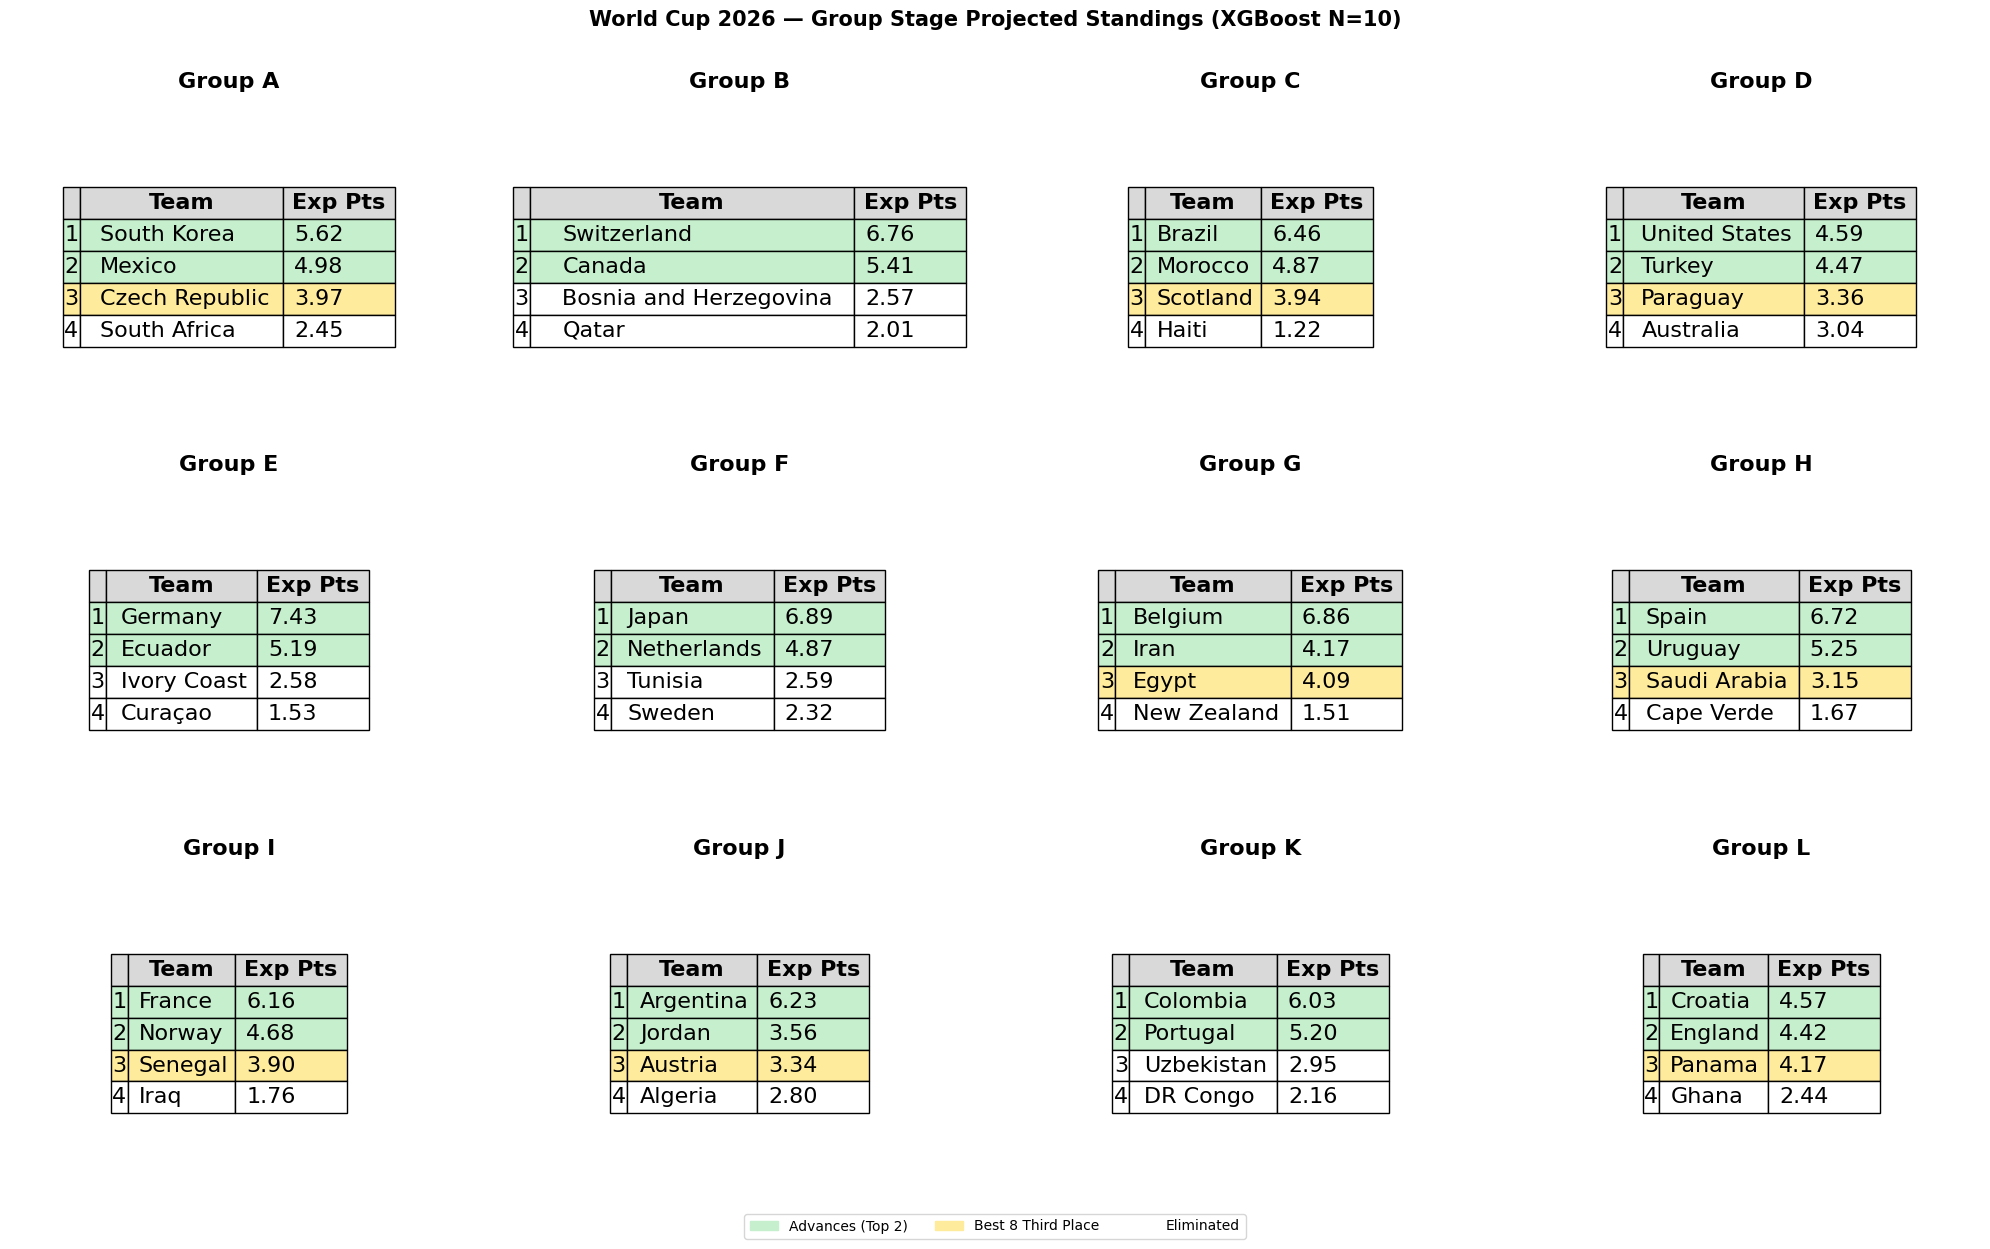

In [35]:
third_place = []
for g, table in group_tables_xgb10.items():
    row = table.iloc[2]
    third_place.append({'group': g, 'team': row['team'], 'expected_pts': row['expected_pts']})
best_8_third_xgb10 = set(pd.DataFrame(third_place).sort_values('expected_pts', ascending=False).head(8)['team'])

fig, axes = plt.subplots(3, 4, figsize=(20, 12))
fig.suptitle('World Cup 2026 — Group Stage Projected Standings (XGBoost N=10)', fontsize=15, fontweight='bold', y=1.01)

for idx, g in enumerate(GROUPS):
    ax = axes[idx // 4][idx % 4]
    ax.axis('off')
    ax.set_title(f'Group {g}', fontweight='bold', fontsize=16, pad=4)

    table = group_tables_xgb10[g]
    cell_text, cell_colors = [], []

    for rank, row in table.iterrows():
        team, pts = row['team'], row['expected_pts']
        if rank <= 2:             bg = COLOR_GREEN
        elif team in best_8_third_xgb10: bg = COLOR_YELLOW
        else:                     bg = COLOR_WHITE
        cell_text.append([str(rank), team, f'{pts:.2f}'])
        cell_colors.append([bg, bg, bg])

    tbl = ax.table(cellText=cell_text, colLabels=['', 'Team', 'Exp Pts'],
                   cellColours=cell_colors, cellLoc='left', loc='center')
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(16)
    tbl.scale(1, 1.5)
    for j in range(3):
        tbl[(0, j)].set_text_props(fontweight='bold')
        tbl[(0, j)].set_facecolor(COLOR_GRAY)
    tbl.auto_set_column_width([0, 1, 2])

legend_patches = [
    mpatches.Patch(color=COLOR_GREEN,  label='Advances (Top 2)'),
    mpatches.Patch(color=COLOR_YELLOW, label='Best 8 Third Place'),
    mpatches.Patch(color=COLOR_WHITE,  label='Eliminated'),
]
fig.legend(handles=legend_patches, loc='lower center', ncol=3, fontsize=10, frameon=True, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
plt.show()

---
## XGBoost (n=20)

In [36]:
fixtures_xgb20 = pd.read_csv(MODEL_DATA_DIR / 'fixtures_2026_n20.csv')

X_fixtures_xgb20 = fixtures_xgb20[FEATURES].values
probs_xgb20 = xgb_best_20.predict_proba(X_fixtures_xgb20)

fixtures_xgb20['p_away'] = probs_xgb20[:, xgb_classes.index(-1)]
fixtures_xgb20['p_draw'] = probs_xgb20[:, xgb_classes.index(0)]
fixtures_xgb20['p_home'] = probs_xgb20[:, xgb_classes.index(1)]

sim_points_xgb20 = {g: {} for g in GROUPS}
for g in GROUPS:
    teams = pd.unique(fixtures_xgb20[fixtures_xgb20['group'] == g][['home_team', 'away_team']].values.ravel())
    sim_points_xgb20[g] = {t: np.zeros(N_SIMS) for t in teams}

for sim in range(N_SIMS):
    for _, row in fixtures_xgb20.iterrows():
        outcome = random.choices([-1, 0, 1], weights=[row['p_away'], row['p_draw'], row['p_home']])[0]
        if outcome == 1:
            sim_points_xgb20[row['group']][row['home_team']][sim] += 3
        elif outcome == -1:
            sim_points_xgb20[row['group']][row['away_team']][sim] += 3
        else:
            sim_points_xgb20[row['group']][row['home_team']][sim] += 1
            sim_points_xgb20[row['group']][row['away_team']][sim] += 1

group_tables_xgb20 = {}
for g in GROUPS:
    rows = [{'team': t, 'expected_pts': round(float(np.mean(pts)), 2)}
            for t, pts in sim_points_xgb20[g].items()]
    table = pd.DataFrame(rows).sort_values('expected_pts', ascending=False).reset_index(drop=True)
    table.index += 1
    group_tables_xgb20[g] = table

print('XGBoost N=20 done.')

XGBoost N=20 done.


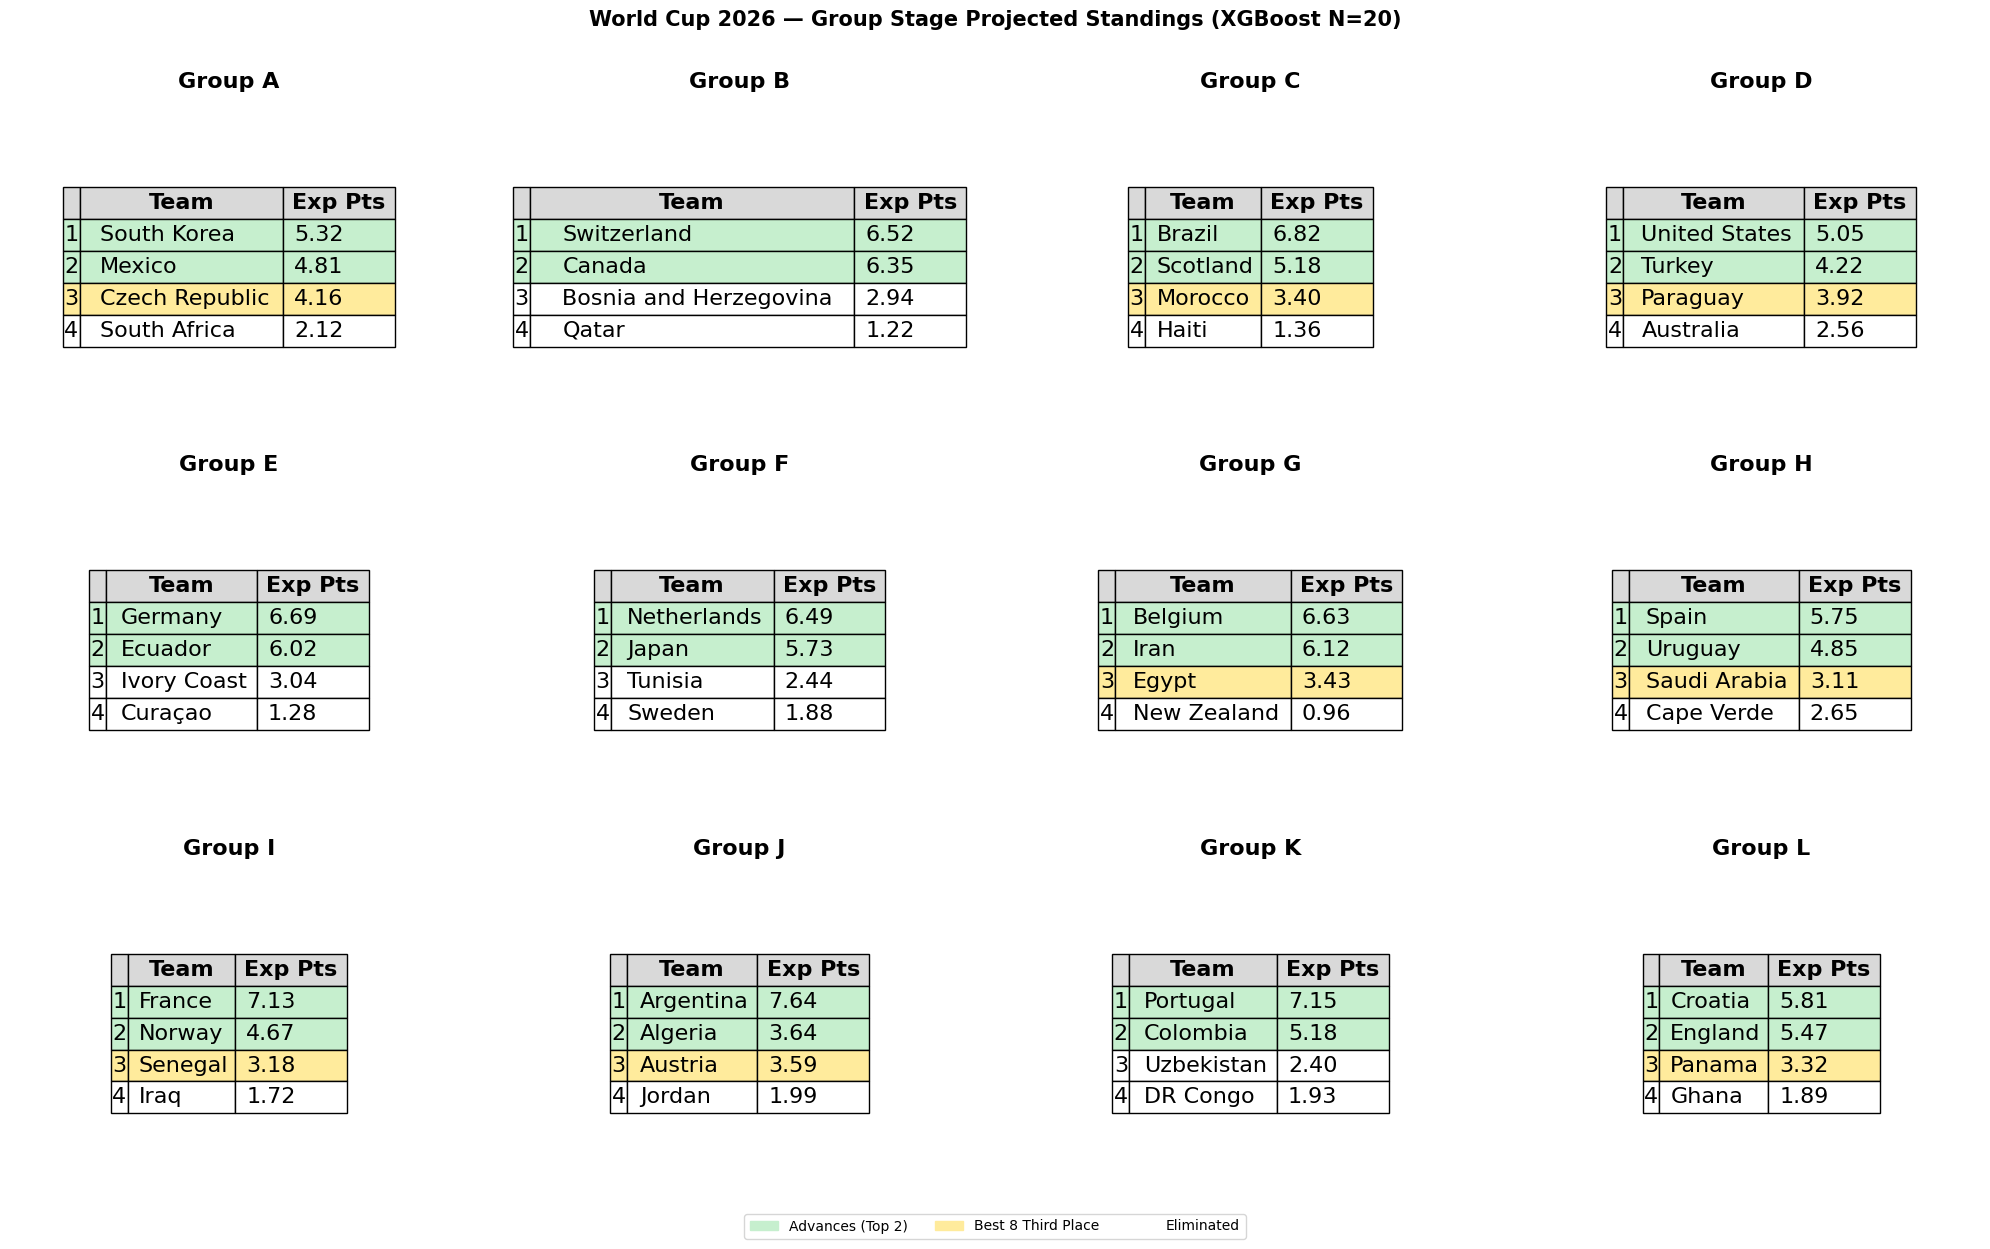

In [37]:
third_place = []
for g, table in group_tables_xgb20.items():
    row = table.iloc[2]
    third_place.append({'group': g, 'team': row['team'], 'expected_pts': row['expected_pts']})
best_8_third_xgb20 = set(pd.DataFrame(third_place).sort_values('expected_pts', ascending=False).head(8)['team'])

fig, axes = plt.subplots(3, 4, figsize=(20, 12))
fig.suptitle('World Cup 2026 — Group Stage Projected Standings (XGBoost N=20)', fontsize=15, fontweight='bold', y=1.01)

for idx, g in enumerate(GROUPS):
    ax = axes[idx // 4][idx % 4]
    ax.axis('off')
    ax.set_title(f'Group {g}', fontweight='bold', fontsize=16, pad=4)

    table = group_tables_xgb20[g]
    cell_text, cell_colors = [], []

    for rank, row in table.iterrows():
        team, pts = row['team'], row['expected_pts']
        if rank <= 2:                    bg = COLOR_GREEN
        elif team in best_8_third_xgb20: bg = COLOR_YELLOW
        else:                            bg = COLOR_WHITE
        cell_text.append([str(rank), team, f'{pts:.2f}'])
        cell_colors.append([bg, bg, bg])

    tbl = ax.table(cellText=cell_text, colLabels=['', 'Team', 'Exp Pts'],
                   cellColours=cell_colors, cellLoc='left', loc='center')
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(16)
    tbl.scale(1, 1.5)
    for j in range(3):
        tbl[(0, j)].set_text_props(fontweight='bold')
        tbl[(0, j)].set_facecolor(COLOR_GRAY)
    tbl.auto_set_column_width([0, 1, 2])

legend_patches = [
    mpatches.Patch(color=COLOR_GREEN,  label='Advances (Top 2)'),
    mpatches.Patch(color=COLOR_YELLOW, label='Best 8 Third Place'),
    mpatches.Patch(color=COLOR_WHITE,  label='Eliminated'),
]
fig.legend(handles=legend_patches, loc='lower center', ncol=3, fontsize=10, frameon=True, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
plt.show()

---
## Predicting the Knockouts with Monte Carlo Simulations

### Define Matchups in each respective bracket based on advancing 3rd place teams

In [38]:
# Round of 32 matchups for each model — (team1, team2) in bracket order
# Derived from group stage results in each model's simulation

BRACKET_LR = [
    ('Germany',      'Scotland'),        # 1E vs 3C
    ('France',       'Paraguay'),        # 1I vs 3D
    ('South Korea',  'Canada'),          # 2A vs 2B
    ('Netherlands',  'Morocco'),         # 1F vs 2C
    ('Portugal',     'Croatia'),         # 2K vs 2L
    ('Spain',        'Austria'),         # 1H vs 2J
    ('Turkey',       'Algeria'),         # 1D vs 3J
    ('Belgium',      'Czech Republic'),  # 1G vs 3A
    ('Brazil',       'Japan'),           # 1C vs 2F
    ('Ecuador',      'Norway'),          # 2E vs 2I
    ('Mexico',       'Ivory Coast'),     # 1A vs 3E
    ('England',      'Senegal'),         # 1L vs 3I
    ('Argentina',    'Uruguay'),         # 1J vs 2H
    ('United States','Iran'),            # 2D vs 2G
    ('Switzerland',  'Egypt'),           # 1B vs 3G
    ('Colombia',     'Panama'),          # 1K vs 3L
]

BRACKET_XGB10 = [
    ('Germany',      'Scotland'),        # 1E vs 3C
    ('France',       'Paraguay'),        # 1I vs 3D
    ('Mexico',       'Canada'),          # 2A vs 2B
    ('Japan',        'Morocco'),         # 1F vs 2C
    ('Portugal',     'England'),         # 2K vs 2L
    ('Spain',        'Jordan'),          # 1H vs 2J
    ('United States','Austria'),         # 1D vs 3J
    ('Belgium',      'Czech Republic'),  # 1G vs 3A
    ('Brazil',       'Netherlands'),     # 1C vs 2F
    ('Ecuador',      'Norway'),          # 2E vs 2I
    ('South Korea',  'Saudi Arabia'),    # 1A vs 3H
    ('Croatia',      'Senegal'),         # 1L vs 3I
    ('Argentina',    'Uruguay'),         # 1J vs 2H
    ('Turkey',       'Iran'),            # 2D vs 2G
    ('Switzerland',  'Egypt'),           # 1B vs 3G
    ('Colombia',     'Panama'),          # 1K vs 3L
]

BRACKET_XGB20 = [
    ('Germany',      'Morocco'),         # 1E vs 3C
    ('France',       'Paraguay'),        # 1I vs 3D
    ('Mexico',       'Canada'),          # 2A vs 2B
    ('Netherlands',  'Scotland'),        # 1F vs 2C
    ('Colombia',     'England'),         # 2K vs 2L
    ('Spain',        'Austria'),         # 1H vs 2J
    ('United States','Algeria'),         # 1D vs 3J
    ('Belgium',      'Czech Republic'),  # 1G vs 3A
    ('Brazil',       'Japan'),           # 1C vs 2F
    ('Ecuador',      'Norway'),          # 2E vs 2I
    ('South Korea',  'Saudi Arabia'),    # 1A vs 3H
    ('Croatia',      'Senegal'),         # 1L vs 3I
    ('Argentina',    'Uruguay'),         # 1J vs 2H
    ('Turkey',       'Iran'),            # 2D vs 2G
    ('Switzerland',  'Egypt'),           # 1B vs 3G
    ('Portugal',     'Panama'),          # 1K vs 3L
]

### Knockout Simulation Helper

In [48]:
import warnings
from collections import defaultdict

ROUNDS  = ['R32', 'R16', 'QF', 'SF', 'Final']
N_SLOTS = [16,     8,     4,    2,    1]

def knockout_win_prob(team1, team2, model, profiles, scaler=None):
    """P(team1 wins) in a knockout match — renormalized to exclude draw."""
    p1 = profiles.loc[team1]
    p2 = profiles.loc[team2]
    X = np.array([[
        p1['elo']       - p2['elo'],
        p1['form']      - p2['form'],
        p1['comp_form'] - p2['comp_form'],
    ]])
    if scaler is not None:
        with warnings.catch_warnings():
            warnings.simplefilter('ignore', UserWarning)
            X = scaler.transform(X)
    probs = model.predict_proba(X)[0]
    # index 0 = away win (-1), index 2 = home win (1) — true for both LR and XGBoost
    p_home, p_away = probs[2], probs[0]
    return p_home / (p_home + p_away)


def simulate_knockout(bracket, model, profiles, n_sims, scaler=None):
    wins = {r: [defaultdict(int) for _ in range(s)] for r, s in zip(ROUNDS, N_SLOTS)}
    apps = {r: [defaultdict(int) for _ in range(s)] for r, s in zip(ROUNDS, N_SLOTS)}
    tournament_wins = defaultdict(int)

    for _ in range(n_sims):
        current = [list(m) for m in bracket]

        for rnd, n in zip(ROUNDS, N_SLOTS):
            next_round = []
            for slot in range(n):
                t1, t2 = current[slot]
                apps[rnd][slot][t1] += 1
                apps[rnd][slot][t2] += 1
                p1 = knockout_win_prob(t1, t2, model, profiles, scaler)
                winner = t1 if random.random() < p1 else t2
                wins[rnd][slot][winner] += 1
                next_round.append(winner)

            if rnd == 'Final':
                tournament_wins[next_round[0]] += 1
            else:
                current = [[next_round[2*i], next_round[2*i+1]] for i in range(n // 2)]

    return tournament_wins, wins, apps


def print_bracket(bracket, model, profiles, model_label, scaler=None):
    """Print bracket using direct head-to-head win probabilities — winner always has >50%."""
    print(f'\n{"="*60}')
    print(f'  {model_label} — Knockout Bracket (Most Likely Path)')
    print(f'{"="*60}')

    current_teams = [list(m) for m in bracket]

    for rnd, n in zip(ROUNDS, N_SLOTS):
        print(f'\n--- {rnd} ---')
        next_teams = []
        for slot in range(n):
            t1, t2 = current_teams[slot]
            p1 = knockout_win_prob(t1, t2, model, profiles, scaler)
            if p1 >= 0.5:
                winner, pct = t1, p1 * 100
            else:
                winner, pct = t2, (1 - p1) * 100
            print(f'  {slot+1:2d}. {t1:<22} vs {t2:<22} →  {winner:<22} ({pct:.1f}%)')
            next_teams.append(winner)

        if rnd != 'Final':
            current_teams = [[next_teams[2*i], next_teams[2*i+1]] for i in range(n // 2)]


def print_top10(tournament_wins, n_sims, model_label):
    print(f'\n{"="*60}')
    print(f'  {model_label} — Top 10 Tournament Win Probabilities')
    print(f'{"="*60}')
    sorted_wins = sorted(tournament_wins.items(), key=lambda x: x[1], reverse=True)[:10]
    for rank, (team, w) in enumerate(sorted_wins, 1):
        bar = '█' * int(w / n_sims * 40)
        print(f'  {rank:2d}. {team:<22} {100*w/n_sims:5.1f}%  {bar}')


print('Helper functions ready.')

Helper functions ready.


### Logistic Regression (n=10) — Knockout Simulation

In [49]:
profiles_n10 = pd.read_csv(MODEL_DATA_DIR / 'profiles_2026_10.csv').set_index('team')

tw_lr, wins_lr, apps_lr = simulate_knockout(
    BRACKET_LR, lr_best, profiles_n10, N_SIMS, scaler=scaler
)

print_top10(tw_lr, N_SIMS, 'Logistic Regression N=10')
print_bracket(BRACKET_LR, lr_best, profiles_n10, 'Logistic Regression N=10', scaler=scaler)


  Logistic Regression N=10 — Top 10 Tournament Win Probabilities
   1. Spain                   28.0%  ███████████
   2. Argentina               16.4%  ██████
   3. France                  14.9%  █████
   4. Colombia                12.8%  █████
   5. England                  7.8%  ███
   6. Netherlands              2.3%  
   7. Germany                  2.2%  
   8. Turkey                   2.2%  
   9. Portugal                 2.2%  
  10. Brazil                   2.1%  

  Logistic Regression N=10 — Knockout Bracket (Most Likely Path)

--- R32 ---
   1. Germany                vs Scotland               →  Germany                (72.6%)
   2. France                 vs Paraguay               →  France                 (87.5%)
   3. South Korea            vs Canada                 →  Canada                 (55.1%)
   4. Netherlands            vs Morocco                →  Netherlands            (61.9%)
   5. Portugal               vs Croatia                →  Portugal               (58.1%)


### XGBoost (n=10) — Knockout Simulation

In [50]:
tw_xgb10, wins_xgb10, apps_xgb10 = simulate_knockout(
    BRACKET_XGB10, xgb_best_10, profiles_n10, N_SIMS, scaler=None
)

print_top10(tw_xgb10, N_SIMS, 'XGBoost N=10')
print_bracket(BRACKET_XGB10, xgb_best_10, profiles_n10, 'XGBoost N=10')


  XGBoost N=10 — Top 10 Tournament Win Probabilities
   1. Spain                   34.0%  █████████████
   2. Argentina               20.5%  ████████
   3. France                  14.4%  █████
   4. Colombia                 7.3%  ██
   5. Brazil                   3.0%  █
   6. Japan                    2.4%  
   7. Ecuador                  2.4%  
   8. England                  2.1%  
   9. Portugal                 2.0%  
  10. Switzerland              1.9%  

  XGBoost N=10 — Knockout Bracket (Most Likely Path)

--- R32 ---
   1. Germany                vs Scotland               →  Germany                (58.4%)
   2. France                 vs Paraguay               →  France                 (84.0%)
   3. Mexico                 vs Canada                 →  Canada                 (53.0%)
   4. Japan                  vs Morocco                →  Japan                  (58.5%)
   5. Portugal               vs England                →  England                (63.5%)
   6. Spain              

### XGBoost (n=20) — Knockout Simulation

In [51]:
profiles_n20 = pd.read_csv(MODEL_DATA_DIR / 'profiles_2026_20.csv').set_index('team')

tw_xgb20, wins_xgb20, apps_xgb20 = simulate_knockout(
    BRACKET_XGB20, xgb_best_20, profiles_n20, N_SIMS, scaler=None
)

print_top10(tw_xgb20, N_SIMS, 'XGBoost N=20')
print_bracket(BRACKET_XGB20, xgb_best_20, profiles_n20, 'XGBoost N=20')


  XGBoost N=20 — Top 10 Tournament Win Probabilities
   1. Argentina               29.4%  ███████████
   2. Spain                   21.4%  ████████
   3. France                  15.4%  ██████
   4. Brazil                   5.1%  ██
   5. Netherlands              4.7%  █
   6. England                  4.3%  █
   7. Portugal                 3.4%  █
   8. Ecuador                  2.3%  
   9. Croatia                  2.3%  
  10. Norway                   2.0%  

  XGBoost N=20 — Knockout Bracket (Most Likely Path)

--- R32 ---
   1. Germany                vs Morocco                →  Morocco                (54.5%)
   2. France                 vs Paraguay               →  France                 (78.8%)
   3. Mexico                 vs Canada                 →  Canada                 (55.8%)
   4. Netherlands            vs Scotland               →  Netherlands            (68.9%)
   5. Colombia               vs England                →  England                (54.1%)
   6. Spain             